In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib

Using matplotlib backend: agg


In [50]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [51]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [52]:
import tensorflow as tf
from tensorflow.keras.models import Sequential # Let's build a neural network layer-by-layer in a Linear fashion
from tensorflow.keras.layers import Dense # Fully connected layer (every neuron connects to every neuron in the next layer)
from tensorflow.keras.layers import Dropout # Randomly drop some neurons during training to prevent overfitting.
from tensorflow.keras.utils import to_categorical # Converts class labels (like 0, 1, 2) into one-hot encoded format(e.g., [1, 0, 0], [0, 1, 0])


In [53]:
from google.colab import files

upload = files.upload()

Saving Iris.csv to Iris (1).csv


In [54]:
df = pd.read_csv('Iris.csv')

In [55]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [56]:
df.shape

(150, 6)

In [57]:
df['Species'].value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [59]:
df.duplicated().sum()

np.int64(0)

In [60]:
sns.pairplot(df, hue='Species')

In [61]:
sns.boxplot(df['SepalLengthCm'])

<Axes: xlabel='PetalWidthCm', ylabel='Density'>

In [62]:
X = df.drop(columns=['Species', 'Id'], axis=1)
y = df['Species']

In [63]:
X.head(), y.head()

(   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
 0            5.1           3.5            1.4           0.2
 1            4.9           3.0            1.4           0.2
 2            4.7           3.2            1.3           0.2
 3            4.6           3.1            1.5           0.2
 4            5.0           3.6            1.4           0.2,
 0    Iris-setosa
 1    Iris-setosa
 2    Iris-setosa
 3    Iris-setosa
 4    Iris-setosa
 Name: Species, dtype: object)

In [64]:
encoder =LabelEncoder()

y_int = encoder.fit_transform(y)
y_int, y.shape

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]),
 (150,))

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y_int, test_size=0.2, random_state=42, stratify=y_int)

In [66]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [67]:
percptron = Perceptron(max_iter=1000, random_state=42)
percptron.fit(X_train_scaled, y_train)

Perceptron(random_state=42)

In [68]:
y_pred_perceptron = percptron.predict(X_test_scaled)

In [69]:
y_pred_perceptron

array([0, 2, 1, 1, 0, 0, 0, 0, 2, 1, 2, 2, 2, 0, 0, 0, 0, 1, 1, 2, 0, 2,
       1, 1, 2, 2, 1, 0, 2, 0])

In [70]:
accuracy_score(y_test, y_pred_perceptron)

0.8666666666666667

In [71]:
print(classification_report(y_test, y_pred_perceptron))

              precision    recall  f1-score   support

           0       0.83      1.00      0.91        10
           1       0.88      0.70      0.78        10
           2       0.90      0.90      0.90        10

    accuracy                           0.87        30
   macro avg       0.87      0.87      0.86        30
weighted avg       0.87      0.87      0.86        30



In [72]:
y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)


In [73]:
model = Sequential([
    Dense(32, input_dim = 4, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')
])

In [74]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [79]:
history = model.fit(X_train_scaled, y_train_cat, epochs=100, batch_size=8, validation_split=0.2, verbose=1)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9792 - loss: 0.0337 - val_accuracy: 1.0000 - val_loss: 0.0123
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9792 - loss: 0.0351 - val_accuracy: 1.0000 - val_loss: 0.0125
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9792 - loss: 0.0368 - val_accuracy: 1.0000 - val_loss: 0.0121
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.9896 - loss: 0.0352 - val_accuracy: 1.0000 - val_loss: 0.0123
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9896 - loss: 0.0343 - val_accuracy: 1.0000 - val_loss: 0.0110
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.9792 - loss: 0.0335 - val_accuracy: 1.0000 - val_loss: 0.0105
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9792 - loss: 0.0351 - val_accuracy: 1.0000 - val_loss: 0.0113
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9792 - loss: 0.0323 - val_accuracy: 1.

In [76]:
X_train_scaled.shape, y_train_cat.shape

((120, 4), (120, 3))

In [83]:
loss, acc = model.evaluate(X_test_scaled, y_test_cat, verbose=0)
print(f'Loss: {loss:.2f}, Accuracy: {acc:.2f}')

Loss: 0.22, Accuracy: 0.97


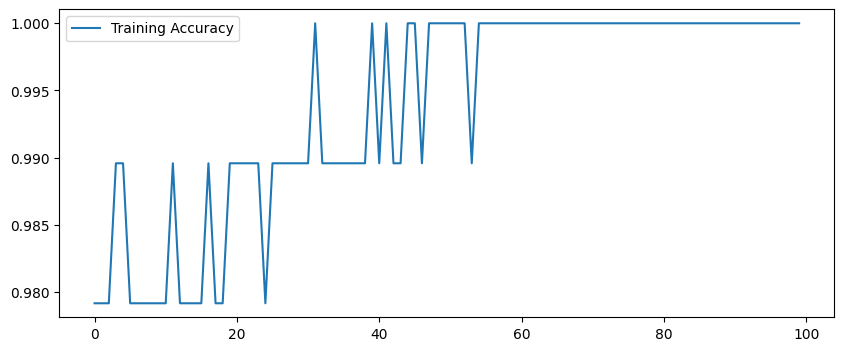

In [88]:
%matplotlib inline
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
# plt.plot(history.history['val_loss'], label='Validation Loss')
# plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()